In [1]:
import addons
import numpy as np
import pandas as pd
import os
import helpers
import random
import math
import math_tools
import matplotlib.pyplot as plt 
from matplotlib.patches import Polygon
from matplotlib.widgets import Slider
from matplotlib.animation import FuncAnimation

/home/hyc_1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Sep 26 2025 04:43:14

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
from scipy.sparse import dok_matrix 
from scipy.fft import fft
from scipy.fft import fftfreq
from scipy import signal
from scipy.signal import butter, lfilter
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def compute_FFT(signal_data,name_,rate,freq_sample= 0.001, lim_x = 200, low_log = 10, high_log =90,fit=False,fit_freq_start = 4.0, fit_freq_end = 14.0,test_p0 = [3000,40,5],welsh_fit = 'alpha',signal_xmin=500,signal_xmax=900,min_x=1,save=True,savefig=False,name_2=None,optional_plot=None):

    plt.rcParams.update({'font.size': 22})
    analysis_interval_start = (addons.analysis_dict["analysis_start"] -500)
    analysis_interval_end = (addons.analysis_dict["analysis_end"] -500)
    analysis_interval_start = int(analysis_interval_start)
    analysis_interval_end = int(analysis_interval_end)
    times_currents = np.linspace(addons.analysis_dict["analysis_start"],addons.analysis_dict["analysis_end"],num=int((addons.analysis_dict["analysis_end"]-addons.analysis_dict["analysis_start"])))

    FFT_Results = {}
    Welsh_Freqs = {}
    Welsh_Powers = {}
    if fit:
        Fit_FFT = {}
        mean_freq = []
        amplitude_freq = []
        sigma_freq = []
        def gaus(x, a, x0, sigma):
            return a*np.exp(-(x-x0)**2/(2*sigma**2))
    #print(len(signal_data[0][analysis_interval_start:analysis_interval_end]))
    for i in signal_data:
        FFT_Results[i] = fft(signal_data[i][analysis_interval_start:analysis_interval_end]-np.mean(signal_data[i][analysis_interval_start:analysis_interval_end]))

    #Calcular los valores de frequencia correspondientes
    freq = fftfreq(len(signal_data[i][analysis_interval_start:analysis_interval_end]),d=freq_sample)
    if fit:
        index_start = int(np.where(freq==fit_freq_start)[0][0])
        index_end = int(np.where(freq==fit_freq_end)[0][0])
    

    plt.figure(figsize=(25, 15))
    colors = ['#d53e4f', '#f46d43', '#fdae61', '#fee08b', '#e6f598', '#abdda4', '#66c2a5', '#3288bd']
    pops = ["L23E","L23I","L4E","L4I","L5E","L5I","L6E","L6I"]
    # Graficar la amplitud en función de la frecuencia
    colors_filter = ['#d53e4f', '#3288bd']


    plt.subplot(2, 1, 1)
    j= 0
    if optional_plot is not None:
        for i in signal_data:
            if i == 0 or i == 2:
                #plt.plot(times_currents,optional_plot[i][analysis_interval_start:analysis_interval_end], c = colors_filter[j], label = pops[i], alpha = 0.5)
                #plt.plot(times_currents,signal_data[i][analysis_interval_start:analysis_interval_end], '--', c = colors_filter[j])
                plt.plot(times_currents,optional_plot[i], c = colors_filter[j], label = pops[i], alpha = 0.5)
                plt.plot(times_currents,signal_data[i], '--', c = colors_filter[j])
                j=j+1
        plt.xlabel('time [ms]')
        plt.ylabel('population activity [spikes]')
        plt.title('background rate  = ' +str(rate))
        plt.xlim(signal_xmin,signal_xmax)    
        plt.grid(True)
        #plt.legend(loc= 'best')
        plt.legend(loc= 'upper left')
        plt.subplot(2, 2, 3)
        j= 0


    else:
        for i in signal_data:
            plt.plot(times_currents,signal_data[i][analysis_interval_start:analysis_interval_end], c = colors[j], label = pops[i])
            #plt.plot(times_currents,signal_data[i], c = colors[j], label = pops[i])
            j=j+1
        plt.xlabel('time [ms]')
        plt.ylabel('population activity [spikes]')
        plt.title('background rate  = ' +str(rate))
        plt.xlim(signal_xmin,signal_xmax)    
        plt.grid(True)
        #plt.legend(loc= 'best')
        plt.legend(loc= 'upper left')
        plt.subplot(2, 2, 3)
        j= 0

    indx = int(len(signal_data[i][analysis_interval_start:analysis_interval_end])/2)
    for i in FFT_Results:
        if fit:
            try:
                Fit_FFT[i], __ = curve_fit(gaus,freq[index_start:index_end],np.abs(FFT_Results[i][index_start:index_end]),p0 = test_p0)
            except RuntimeError:
                print("Error in curve fitting for index:", i)
                Fit_FFT[i] = [0, 0, 0]
            if Fit_FFT[i][1] <= 0:
                Fit_FFT[i][1] = 0
                Fit_FFT[i][0] = 0
            if Fit_FFT[i][1] >= 15 and welsh_fit == 'alpha':
                Fit_FFT[i][1] = 0
                Fit_FFT[i][0] = 0
            mean_freq = np.append(mean_freq,Fit_FFT[i][1])
            amplitude_freq = np.append(amplitude_freq,Fit_FFT[i][0])
            sigma_freq = np.append(sigma_freq,Fit_FFT[i][2])

            plt.plot(freq[index_start:index_end],gaus(freq[index_start:index_end],*Fit_FFT[i]),'--', c = colors[j])
        plt.plot(freq[:indx], np.abs(FFT_Results[i])[:indx],c = colors[j], label = pops[i])
        j=j+1
    plt.xlabel('frequency [Hz]')
    plt.ylabel('ampltidue [spikes]')
    plt.figtext(0.5,0.48,"Fast Fourier Transform", va="center", ha="center", size=22)
    plt.grid(True)
    plt.xlim(min_x,lim_x)
    #plt.ylim(0,lim_y)
    #plt.legend(loc= 'best')

    plt.subplot(2, 2, 4)
    j= 0
    indx = int(len(signal_data[i][analysis_interval_start:analysis_interval_end])/2)
    for i in FFT_Results:
        if fit:
            plt.plot(freq[index_start:index_end],20 * np.log10(gaus(freq[index_start:index_end],*Fit_FFT[i])),'--', c = colors[j])
        plt.plot(freq[:indx], 20 * np.log10(np.abs(FFT_Results[i])[:indx]),c = colors[j], label = pops[i])
        j=j+1
    plt.xlabel('frequency [Hz]')
    plt.ylabel('amplitude [dB]')
    #plt.title('Voltage (minus the mean) FFT')
    plt.grid(True)
    plt.xlim(min_x,lim_x)
    plt.ylim(low_log,high_log)

    result_fourier = {}

    for i in FFT_Results:
        result_fourier[i] = np.abs(FFT_Results[i])[:indx]
    results_freq = freq[:indx]

    if savefig:
        if save:
            if welsh_fit == 'alpha':
                name = name_2 + '/results/fft_alpha.svg'
            elif welsh_fit == 'gamma':
                name = name_2 + '/results/fft_gamma.svg'
        else:
            name = name_2 + '/results/fft.svg'
        namedir = name_2 + '/results/'
        os.makedirs(os.path.dirname(namedir), exist_ok=True)
        plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.close()

    if save:
        pops = [0,1,2,3,4,5,6,7]
        np.savetxt(name_, np.c_[pops,mean_freq, amplitude_freq, sigma_freq], fmt = '%.2f', header = 'Pops mean_freq amplitude sigma', delimiter = ' ')

    return result_fourier, results_freq, Welsh_Freqs, Welsh_Powers, indx

In [3]:
def NormalizeData(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [4]:
super_name = 'data_background_rate_big'
#super_name = 'data_background_rate_fig_1'

In [ ]:
import re

list_dirs = os.listdir(super_name)

def _bg_rate_from_dirname(d):
    """Numeric background rate encoded in a directory name, np.inf if absent."""
    m_ = re.search(r"\d+(?:\.\d+)?", d)
    return float(m_.group()) if m_ else np.inf

# sort numerically by the encoded rate: plain sorted() puts '10.0' before '5.0'
list_dirs = sorted(list_dirs, key=_bg_rate_from_dirname)
bg_rates_parsed = np.array([_bg_rate_from_dirname(d) for d in list_dirs])

names = ["L23E", "L23I", "L4E", "L4I", "L5E", "L5I", "L6E", "L6I"]
num_trials = 10

fs_sampling = 1000
freq_sample = 1 / fs_sampling
freq_sample_welsh = 5000

# Every trace is padded/trimmed to L_need samples BEFORE compute_FFT, so a
# 4999-sample rebuild artefact can no longer produce the x/y length-mismatch
# crash or break the Fourier array slots below.
L_need = int(addons.analysis_dict["analysis_end"] - 500)
MAX_PAD = 10  # samples; shorter than L_need - MAX_PAD is a data error, not an off-by-one

def _normalise_length(x, path):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    if x.ndim != 1:
        raise ValueError(f"{path}: expected a 1-D trace, got shape {x.shape}")
    if len(x) < L_need - MAX_PAD:
        raise ValueError(f"{path}: trace has {len(x)} samples, need >= {L_need - MAX_PAD}")
    if len(x) < L_need:
        print(f"note: edge-padding {path} from {len(x)} to {L_need} samples")
        x = np.pad(x, (0, L_need - len(x)), mode="edge")
    return x

# allocated after the first spectrum so the bin count is derived from the
# data instead of being hardcoded to 2500
Fourier_data = None
Fourier_data_final = None

for i, dir in enumerate(list_dirs):
    name = super_name + "/" + str(dir)
    list_dirs_2 = os.listdir(name)
    try:
        list_dirs_2.remove('results')
    except ValueError:
        pass
    list_dirs_2 = sorted(list_dirs_2)
    for j, dir_2 in enumerate(list_dirs_2):
        if j >= num_trials:
            print(f"warning: {name} has more than {num_trials} trial dirs, skipping extras")
            break
        name_2 = name + '/' + str(dir_2)
        neuron_id = np.loadtxt((os.path.join(name_2, "population_nodeids.dat")), dtype=int)
        num_neurons = []
        for l in range(len(neuron_id)):
            num_neurons = np.append(num_neurons, int(neuron_id[l][1] - neuron_id[l][0] + 1))
        num_neurons = num_neurons.astype(int)
        pop_activity = {}
        for m in range(len(num_neurons)):
            path_m = name_2 + "/measurements/pop_activities_1ms/pop_activity_" + str(m) + ".dat"
            pop_activity[m] = _normalise_length(np.loadtxt(path_m), path_m)
        Fourier_data_help, FFT_frequencies, Welsh_frequencies, Welsh_signal, FFT_index = compute_FFT(pop_activity, name_=name_2, rate=dir, lim_x=100, high_log=130, low_log=0, freq_sample=freq_sample, signal_xmax=700, save=False, savefig=True, name_2=name_2)
        if Fourier_data is None:
            n_bins = len(Fourier_data_help[0])
            Fourier_data = np.zeros((len(list_dirs), num_trials, 8, n_bins))
            Fourier_data_final = np.zeros((len(list_dirs), 8, n_bins))
        for m in range(len(num_neurons)):
            Fourier_data[i, j, m, :] = (Fourier_data_help[m])
    Fourier_data_final[i, :, :] = np.mean(Fourier_data[i, :, :, :], axis=0)


In [ ]:
fs = 26
# use the rates parsed from the directory names; fall back to the old linspace
bg_rates = bg_rates_parsed if 'bg_rates_parsed' in globals() else np.linspace(5, 20, len(list_dirs))
os.makedirs("Figure2", exist_ok=True)

plt.subplots(2,4,figsize=(30,15),sharex='col',sharey='col',dpi=300)

for j in range(8):
    plt.subplot(2,4,j+1)
    #plt.contourf(bg_rates,FFT_frequencies,np.transpose(Fourier_data_final[:,j,:]), levels=300, cmap='YlGnBu_r',norm=plt.Normalize(vmin=0, vmax=43539.306869772285))
    plt.contourf(bg_rates,FFT_frequencies,np.transpose(NormalizeData(Fourier_data_final[:,j,:])), levels=300, cmap='viridis') #test plasma
    plt.ylim(top=110)
    if j in [4,5,6,7]:
        plt.xlabel('background rate [spikes/s]', fontsize=fs)
    if j in [0,4]:
         plt.ylabel('frequency [Hz]', fontsize=fs)
    plt.title(names[j], fontsize = fs)


#plt.suptitle('FFT of population activity across all populations', fontsize=fs+4)
plt.tight_layout()
cbar = plt.colorbar(label='normalised amplitude', orientation='vertical',aspect=60,ax=plt.gcf().get_axes())
cbar.ax.tick_params(labelsize=fs)
cbar.set_label('normalised amplitude', fontsize=fs)
plt.savefig("Figure2/FFT_all_populations.svg", bbox_inches='tight', dpi=600)
#cbar.set_ticks([0,43539.306869772285])
#cbar.set_ticklabels(['min','max'])


### Subharmonic vs. two-oscillator test (Sections 2-4 / 2-7)

The spectra alone can't distinguish whether the ~40 Hz component is a subharmonic of a single ~80 Hz rhythm (large population events skipping every other cycle under strong inhibition) from two independently generated oscillations from distinct sub-circuits (Bos et al., 2016), since a locally generated rhythm is inherited by every downstream population regardless of origin.

The three cells below implement the time-domain tests that bear on this and are a **standalone unit**: after a fresh kernel restart they run without the FFT cells at the top (imports are local, and the analysis window falls back to `ANALYSIS_START_MS` / `ANALYSIS_END_MS` globals if `addons` is not importable).

- **Subharmonic power ratio** `P(f0/2)/P(f0)`, band-integrated around the detected high-gamma peak f0 and its half frequency. A period-doubled rhythm keeps this ratio in a stable, population-independent range; independent oscillators do not.
- **2:1 phase-locking index** `lambda = |<exp(i(2*phi_low - phi_high))>|` between the Hilbert phases of the band-passed f0/2 and f0 components, against a circular-shift surrogate null.
- **Bicoherence at (f0/2, f0/2)**, which sums to f0, against a phase-randomized surrogate null.

Stars in the figure mark group-level significance per (rate, population): the across-trial mean of the observed statistic exceeds a bootstrap null of across-trial surrogate means (95th percentile for phase locking, 99th for bicoherence).

The driver checkpoints to `Figure2/phase_locking_bicoherence.npz` after every background rate and skips finished rates on re-run, so an interrupted sweep resumes instead of restarting. The last cell renders the single three-panel figure from that file alone, so it can be re-styled without redoing the sweep (`PAPER_STYLE` switches between the mockup look and the paper style).


In [5]:
# --- Subharmonic vs. two-oscillator statistics: function block ---------------
# This cell plus the two below (driver, plot) form a standalone unit: after a
# kernel restart you can run just these three cells, without the FFT cells at
# the top of the notebook. Imports are local on purpose.

import os
import numpy as np
from scipy.signal import butter, sosfiltfilt, hilbert

# ----------------------------------------------------------------------
# 1. Band-pass filtering + instantaneous phase
# ----------------------------------------------------------------------

def bandpass(x, f_lo, f_hi, fs, order=4):
    """Zero-phase Butterworth band-pass filter (SOS form, filtfilt)."""
    nyq = fs / 2.0
    sos = butter(order, [f_lo / nyq, f_hi / nyq], btype="band", output="sos")
    return sosfiltfilt(sos, x)


def inst_phase(x):
    """Instantaneous phase via the analytic signal (Hilbert transform)."""
    return np.angle(hilbert(x))


def extract_phases(x, fs, low_band, high_band, order=4):
    """Band-pass one trace into the f0/2 and f0 components, return phases."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    low = bandpass(x, *low_band, fs=fs, order=order)
    high = bandpass(x, *high_band, fs=fs, order=order)
    return inst_phase(low), inst_phase(high)


def amplitude_spectrum(x, fs):
    """One-sided amplitude spectrum |rfft| of a mean-subtracted trace."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    amp = np.abs(np.fft.rfft(x))
    return freqs, amp


def bands_from_f0(freqs, amp, high_search=(60.0, 100.0), half_width=6.0):
    """
    Anchor both bands on the high-gamma peak: find f0 as the amplitude
    maximum inside high_search, then take
        high_band = f0   +/- half_width
        low_band  = f0/2 +/- half_width.
    Centring the low band on f0/2, rather than on an independently detected
    low peak, is what the subharmonic hypothesis predicts, and it is the
    frequency pair the bicoherence is evaluated at.
    """
    freqs = np.asarray(freqs)
    amp = np.asarray(amp)
    lo, hi = high_search
    mask = (freqs >= lo) & (freqs <= hi)
    if not np.any(mask):
        raise ValueError(f"high_search {high_search} lies outside the spectral axis")
    f0 = float(freqs[mask][np.argmax(amp[mask])])
    f_half = 0.5 * f0
    low_band = (max(1.0, f_half - half_width), f_half + half_width)
    high_band = (max(1.0, f0 - half_width), f0 + half_width)
    return low_band, high_band, f_half, f0


def band_power(freqs, amp, f_center, half_width):
    """Integrated power (sum of |X|^2) within f_center +/- half_width."""
    freqs = np.asarray(freqs)
    amp = np.asarray(amp)
    mask = (freqs >= f_center - half_width) & (freqs <= f_center + half_width)
    if not np.any(mask):
        return np.nan
    return float(np.sum(amp[mask] ** 2))


def subharmonic_power_ratio(freqs, amp, f0, half_width=6.0):
    """P(f0/2) / P(f0), both band-integrated over +/- half_width."""
    p_half = band_power(freqs, amp, 0.5 * f0, half_width)
    p_full = band_power(freqs, amp, f0, half_width)
    if not np.isfinite(p_full) or p_full <= 0:
        return np.nan
    return p_half / p_full


# ----------------------------------------------------------------------
# 2. n:m phase-locking index
# ----------------------------------------------------------------------

def nm_plv(phi_low, phi_high, n=2, m=1):
    """
    lambda = |< exp(i*(n*phi_low - m*phi_high)) >|

    Default n=2, m=1 is the relation predicted by the subharmonic account:
    the ~80 Hz phase advances twice per ~40 Hz cycle, so 2*phi_low - phi_high
    should sit near a fixed offset if the two bands are really one rhythm
    and its subharmonic.
    """
    phi_low = np.asarray(phi_low)
    phi_high = np.asarray(phi_high)
    L = min(len(phi_low), len(phi_high))
    diff = n * phi_low[:L] - m * phi_high[:L]
    return np.abs(np.mean(np.exp(1j * diff)))


def plv_surrogate_test(phi_low, phi_high, n=2, m=1, n_surr=500, alpha=0.05, rng=None):
    """
    Null distribution of the n:m PLV built by circularly shifting phi_high
    by a random lag before recombining with phi_low. This preserves each
    band's own autocorrelation/frequency content but destroys any fixed
    phase relation between them.

    Returns: observed_lambda, surrogate_values (n_surr,), threshold (alpha)
    """
    rng = np.random.default_rng(rng)
    L = min(len(phi_low), len(phi_high))
    phi_low = phi_low[:L]
    phi_high = phi_high[:L]

    observed = nm_plv(phi_low, phi_high, n=n, m=m)
    surrogate_vals = np.empty(n_surr)
    for k in range(n_surr):
        shift = rng.integers(1, L - 1)
        surrogate_vals[k] = nm_plv(phi_low, np.roll(phi_high, shift), n=n, m=m)
    threshold = np.quantile(surrogate_vals, 1 - alpha)
    return observed, surrogate_vals, threshold


# ----------------------------------------------------------------------
# 3. Bicoherence at a single frequency pair, e.g. (f0/2, f0/2)
# ----------------------------------------------------------------------

def _segment_epochs(x, fs, seg_len_s, overlap):
    x = np.asarray(x)
    if x.ndim != 1:
        raise ValueError(
            f"_segment_epochs expects a 1-D trace, got shape {x.shape} "
            f"(dtype {x.dtype}); check the pop_activity file format.")
    seg_len = int(round(seg_len_s * fs))
    step = max(1, int(round(seg_len * (1 - overlap))))
    n_seg = 1 + (len(x) - seg_len) // step
    if n_seg < 1:
        raise ValueError("Signal shorter than one bicoherence segment; "
                         "reduce seg_len_s or check fs.")
    return np.stack([x[i * step: i * step + seg_len] for i in range(n_seg)])


def bicoherence_value(x, fs, f1, f2, seg_len_s=0.5, overlap=0.5, window=True):
    """
    Direct-method bicoherence at a single frequency pair (f1, f2):

        b(f1,f2) = |< X(f1) X(f2) X*(f1+f2) >|
                   / sqrt( <|X(f1)X(f2)|^2> * <|X(f1+f2)|^2> )

    averaged over overlapping segments. x is the raw (unfiltered)
    population-rate trace; do not band-pass first, or the coupling the
    statistic is meant to detect gets filtered away.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    epochs = _segment_epochs(x, fs, seg_len_s, overlap)
    n_seg, seg_len = epochs.shape
    if window:
        epochs = epochs * np.hanning(seg_len)

    freqs = np.fft.rfftfreq(seg_len, d=1.0 / fs)
    X = np.fft.rfft(epochs, axis=1)

    def nearest(f):
        return int(np.argmin(np.abs(freqs - f)))

    i1, i2, i12 = nearest(f1), nearest(f2), nearest(f1 + f2)
    x1, x2, x12c = X[:, i1], X[:, i2], np.conj(X[:, i12])

    num = np.abs(np.mean(x1 * x2 * x12c))
    denom = np.sqrt(np.mean(np.abs(x1 * x2) ** 2) * np.mean(np.abs(x12c) ** 2))
    return num / denom if denom > 0 else np.nan


def _phase_randomize(x, rng):
    """Fourier phase-randomized surrogate: same amplitude spectrum, phases
    scrambled -> destroys any cross-frequency phase coupling."""
    n = len(x)
    X = np.fft.rfft(x)
    random_phases = rng.uniform(0, 2 * np.pi, size=X.shape)
    random_phases[0] = 0.0
    if n % 2 == 0:
        random_phases[-1] = 0.0
    X_surr = np.abs(X) * np.exp(1j * random_phases)
    x_surr = np.fft.irfft(X_surr, n=n)
    if x_surr.shape != np.shape(x):
        raise RuntimeError(
            f"_phase_randomize changed the trace shape: {np.shape(x)} -> {x_surr.shape}")
    return x_surr


def bicoherence_surrogate_test(x, fs, f1, f2, seg_len_s=0.5, overlap=0.5,
                               n_surr=200, alpha=0.05, rng=None):
    """
    Null distribution of bicoherence(f1,f2) from phase-randomized surrogates
    of the same signal (matched power spectrum, no cross-frequency phase
    structure).

    Returns: observed_bicoherence, surrogate_values (n_surr,), threshold (alpha)
    """
    rng = np.random.default_rng(rng)
    observed = bicoherence_value(x, fs, f1, f2, seg_len_s, overlap)
    surrogate_vals = np.empty(n_surr)
    for k in range(n_surr):
        x_surr = _phase_randomize(x, rng)
        surrogate_vals[k] = bicoherence_value(x_surr, fs, f1, f2, seg_len_s, overlap)
    threshold = np.quantile(surrogate_vals, 1 - alpha)
    return observed, surrogate_vals, threshold


# ----------------------------------------------------------------------
# 4. One-call convenience wrapper: raw trace -> all three statistics
# ----------------------------------------------------------------------

def phase_locking_and_bicoherence(x, fs, freqs=None, amp=None,
                                  high_search=(60.0, 100.0), half_width=6.0,
                                  n=2, m=1, seg_len_s=0.5, overlap=0.5,
                                  n_surr_plv=500, n_surr_bic=200,
                                  alpha=0.05, rng=None):
    """
    Full pipeline for one population-rate trace x sampled at fs (Hz):
      - locate f0 inside high_search on the trace's own amplitude spectrum
        (or on a spectrum passed in via freqs/amp, which must be on a real-Hz
        axis consistent with fs) and anchor the low band at f0/2
      - n:m PLV lambda with a circular-shift surrogate test
      - bicoherence at (f0/2, f0/2) with a phase-randomised surrogate test
      - subharmonic power ratio P(f0/2)/P(f0)

    Returns a dict that includes the raw surrogate values of both statistics
    so the caller can build group-level (across-trial) null distributions.
    """
    rng = np.random.default_rng(rng)
    if freqs is None or amp is None:
        freqs, amp = amplitude_spectrum(x, fs)
    low_band, high_band, f_half, f0 = bands_from_f0(freqs, amp, high_search, half_width)

    phi_low, phi_high = extract_phases(x, fs, low_band, high_band)
    lam, lam_surr, lam_thr = plv_surrogate_test(
        phi_low, phi_high, n=n, m=m, n_surr=n_surr_plv, alpha=alpha, rng=rng)

    bic, bic_surr, bic_thr = bicoherence_surrogate_test(
        x, fs, f_half, f_half, seg_len_s=seg_len_s, overlap=overlap,
        n_surr=n_surr_bic, alpha=alpha, rng=rng)

    ratio = subharmonic_power_ratio(freqs, amp, f0, half_width)

    return {
        "low_band": low_band, "high_band": high_band,
        "f_half": f_half, "f0": f0,
        "lambda": lam, "lambda_threshold": lam_thr,
        "lambda_surrogates": lam_surr,
        "bicoherence": bic, "bicoherence_threshold": bic_thr,
        "bicoherence_surrogates": bic_surr,
        "power_ratio": ratio,
    }


In [6]:
"""
Driver for the Figure 2 subharmonic tests: 2:1 phase locking, bicoherence
and subharmonic power ratio across the background-rate sweep.

Motivation
----------
The FFT panels above show power at ~40 Hz and ~80 Hz in every population, but
spectra alone cannot distinguish a subharmonic of a single ~80 Hz rhythm
(large population events skipping cycles under strong inhibition) from two
independently generated oscillations (Bos et al., 2016), since a locally
generated rhythm is inherited by every downstream population either way.
This cell asks whether the ~40 Hz component carries the time-domain
signatures of a genuine subharmonic of the ~80 Hz rhythm.

What it measures
----------------
For every background rate, trial and population trace (analysis window only):
  1. f0, the high-gamma spectral peak of that trace, and the anchored bands
     f0 +/- HALF_WIDTH and f0/2 +/- HALF_WIDTH.
  2. lambda, the 2:1 phase-locking value, against a circular-shift surrogate
     null.
  3. Bicoherence at (f0/2, f0/2), against a phase-randomised surrogate null.
  4. The subharmonic power ratio P(f0/2)/P(f0), band-integrated.
Group-level significance per (rate, population): the across-trial mean of the
observed statistic is compared with a bootstrap null of across-trial means
drawn from the stored surrogates (threshold at 1 - ALPHA_PLV for lambda and
1 - ALPHA_BIC for bicoherence). Results are checkpointed to OUT_NPZ after
every background rate, and finished rates are skipped on re-run (RESUME).

Usage
-----
Run the function cell above, then this cell, then the plot cell below. Works
from a fresh kernel and does not need the FFT cells at the top. To replot
without recomputing, run only the plot cell (it reads OUT_NPZ). To force a
full recompute, set RESUME to False or delete OUT_NPZ. On a machine without
the addons module, define ANALYSIS_START_MS / ANALYSIS_END_MS before running
this cell. Optional overrides for testing: define CFG_OVERRIDE = {...} with
any subset of the CFG keys before running.
"""

import json
import time

# ------------------------------- config --------------------------------
CFG = {
    "SUPER_NAME": "data_background_rate_big",
    "NAMES": ["L23E", "L23I", "L4E", "L4I", "L5E", "L5I", "L6E", "L6I"],
    "NUM_TRIALS": 10,
    "TRACE_T0_MS": 500.0,              # on-disk traces start at t = 500 ms
    # candidate trace sources, tried in order; (subdir, sampling rate in Hz).
    # The old driver read pop_activities at 0.2 ms bins but passed fs=1000
    # downstream; here the fs travels with the file that was actually read.
    "SOURCES": [
        ("pop_activities_1ms", 1000.0),
        ("pop_activities", 5000.0),
    ],
    "HIGH_SEARCH": (60.0, 100.0),
    "HALF_WIDTH": 6.0,
    "SEG_LEN_S": 0.5,
    "OVERLAP": 0.5,
    "N_SURR_PLV": 500,
    "N_SURR_BIC": 200,
    "ALPHA_PLV": 0.05,   # stars in the figure: p < 0.05 vs. surrogate
    "ALPHA_BIC": 0.01,   # stars in the figure: above the 99th pct of the null
    "B_BOOT": 2000,      # bootstrap draws for the across-trial mean null
    "RESUME": True,
    "OUT_NPZ": os.path.join("Figure2", "phase_locking_bicoherence.npz"),
}
CFG.update(globals().get("CFG_OVERRIDE", {}))

# ------------------------- analysis window -----------------------------
try:
    import addons
    ANALYSIS_START_MS = float(addons.analysis_dict["analysis_start"])
    ANALYSIS_END_MS = float(addons.analysis_dict["analysis_end"])
except Exception:
    ANALYSIS_START_MS = globals().get("ANALYSIS_START_MS", None)
    ANALYSIS_END_MS = globals().get("ANALYSIS_END_MS", None)
if ANALYSIS_START_MS is None or ANALYSIS_END_MS is None:
    raise RuntimeError("addons is not importable here; define ANALYSIS_START_MS "
                       "and ANALYSIS_END_MS (in ms) before running this cell.")

# -------------------------- directory layout ---------------------------
import re

def _bg_rate_from_dirname(d):
    m_ = re.search(r"\d+(?:\.\d+)?", d)
    return float(m_.group()) if m_ else np.inf

def _trial_key(d):
    m_ = re.search(r"(\d+)\s*$", d)
    return (int(m_.group(1)) if m_ else np.inf, d)

bg_dirs = sorted(os.listdir(CFG["SUPER_NAME"]), key=_bg_rate_from_dirname)
bg_rates = np.array([_bg_rate_from_dirname(d) for d in bg_dirs])

names = list(CFG["NAMES"])
n_bg, n_pops, num_trials = len(bg_dirs), len(names), CFG["NUM_TRIALS"]

# ------------------------------ storage --------------------------------
Lambda = np.full((n_bg, num_trials, n_pops), np.nan)
Lambda_thr = np.full((n_bg, num_trials, n_pops), np.nan)
Bicoh = np.full((n_bg, num_trials, n_pops), np.nan)
Bicoh_thr = np.full((n_bg, num_trials, n_pops), np.nan)
Ratio = np.full((n_bg, num_trials, n_pops), np.nan)
F0 = np.full((n_bg, num_trials, n_pops), np.nan)
Lambda_group_thr = np.full((n_bg, n_pops), np.nan)
Bicoh_group_thr = np.full((n_bg, n_pops), np.nan)
Lambda_sig = np.zeros((n_bg, n_pops), dtype=bool)
Bicoh_sig = np.zeros((n_bg, n_pops), dtype=bool)
done_mask = np.zeros(n_bg, dtype=bool)

# resume from the checkpoint if layout and shapes still match
if CFG["RESUME"] and os.path.exists(CFG["OUT_NPZ"]):
    try:
        with np.load(CFG["OUT_NPZ"], allow_pickle=False) as d_:
            if list(d_["bg_dirs"]) == bg_dirs and d_["Lambda"].shape == Lambda.shape:
                Lambda, Lambda_thr = d_["Lambda"], d_["Lambda_thr"]
                Bicoh, Bicoh_thr = d_["Bicoh"], d_["Bicoh_thr"]
                Ratio, F0 = d_["Ratio"], d_["F0"]
                Lambda_group_thr = d_["Lambda_group_thr"]
                Bicoh_group_thr = d_["Bicoh_group_thr"]
                Lambda_sig = d_["Lambda_sig"].astype(bool)
                Bicoh_sig = d_["Bicoh_sig"].astype(bool)
                done_mask = d_["done_mask"].astype(bool)
                print(f"resuming: {int(done_mask.sum())}/{n_bg} background rates already done")
            else:
                print("checkpoint exists but layout changed, starting fresh")
    except Exception as err_:
        print(f"could not read checkpoint ({err_}), starting fresh")

def _save_checkpoint():
    os.makedirs(os.path.dirname(CFG["OUT_NPZ"]), exist_ok=True)
    np.savez(CFG["OUT_NPZ"],
             bg_dirs=np.array(bg_dirs), bg_rates=bg_rates, names=np.array(names),
             Lambda=Lambda, Lambda_thr=Lambda_thr,
             Bicoh=Bicoh, Bicoh_thr=Bicoh_thr,
             Ratio=Ratio, F0=F0,
             Lambda_group_thr=Lambda_group_thr, Bicoh_group_thr=Bicoh_group_thr,
             Lambda_sig=Lambda_sig, Bicoh_sig=Bicoh_sig,
             done_mask=done_mask,
             config=np.array(json.dumps(CFG)))

def _load_trace(trial_path, p):
    """Return (raw trace, fs of that file, path); fs travels with the file."""
    for subdir, fs_src in CFG["SOURCES"]:
        path = os.path.join(trial_path, "measurements", subdir, f"pop_activity_{p}.dat")
        if os.path.exists(path):
            return np.loadtxt(path), float(fs_src), path
    raise FileNotFoundError(f"no pop_activity_{p}.dat under {trial_path}/measurements")

def _bootstrap_mean_threshold(surr_per_trial, q, n_boot, rng):
    """Quantile q of the null distribution of the across-trial mean statistic,
    built by drawing one surrogate value per trial and averaging."""
    ks = [np.asarray(s) for s in surr_per_trial if s is not None and len(s)]
    if not ks:
        return np.nan
    draws = np.stack([k[rng.integers(0, len(k), size=n_boot)] for k in ks])
    return float(np.quantile(draws.mean(axis=0), q))

# ------------------------------- sweep ---------------------------------
failures = []
sources_used = set()
debug_dir = os.path.join("Figure2", "debug_failed_traces")

for i, bg_dir in enumerate(bg_dirs):
    if done_mask[i]:
        continue
    t_rate = time.time()
    print(f"[{i + 1}/{n_bg}] {bg_dir}", flush=True)
    name = os.path.join(CFG["SUPER_NAME"], bg_dir)
    trial_dirs = sorted((d for d in os.listdir(name) if d != "results"), key=_trial_key)
    if len(trial_dirs) > num_trials:
        print(f"  warning: {len(trial_dirs)} trial dirs, using the first {num_trials}")
        trial_dirs = trial_dirs[:num_trials]

    lam_surr_store = [[] for _ in range(n_pops)]
    bic_surr_store = [[] for _ in range(n_pops)]

    for j, trial_dir in enumerate(trial_dirs):
        trial_path = os.path.join(name, trial_dir)
        for p in range(n_pops):
            try:
                x, fs_trace, path = _load_trace(trial_path, p)
                sources_used.add(os.path.basename(os.path.dirname(path)))
                x = np.atleast_1d(np.asarray(x, dtype=float))
                if x.ndim != 1:
                    raise ValueError(f"trace is not 1-D: shape {x.shape}")
                i0 = int(round((ANALYSIS_START_MS - CFG["TRACE_T0_MS"]) * fs_trace / 1000.0))
                i1 = int(round((ANALYSIS_END_MS - CFG["TRACE_T0_MS"]) * fs_trace / 1000.0))
                if i0 < 0:
                    raise ValueError(f"analysis window starts before the trace (i0 = {i0})")
                x = x[i0:i1]
                if len(x) < int(CFG["SEG_LEN_S"] * fs_trace):
                    continue  # need at least one bicoherence segment
                if not np.all(np.isfinite(x)):
                    raise ValueError("trace contains NaN or Inf")

                result = phase_locking_and_bicoherence(
                    x, fs=fs_trace,
                    high_search=CFG["HIGH_SEARCH"], half_width=CFG["HALF_WIDTH"],
                    seg_len_s=CFG["SEG_LEN_S"], overlap=CFG["OVERLAP"],
                    n_surr_plv=CFG["N_SURR_PLV"], n_surr_bic=CFG["N_SURR_BIC"],
                    alpha=CFG["ALPHA_PLV"], rng=i * 1000 + j * 10 + p)
            except Exception as err:
                failures.append((i, j, p, trial_path, f"{type(err).__name__}: {err}"))
                try:
                    os.makedirs(debug_dir, exist_ok=True)
                    np.save(os.path.join(debug_dir, f"trace_i{i}_j{j}_p{p}.npy"),
                            np.loadtxt(path))
                except Exception:
                    pass
                continue

            Lambda[i, j, p] = result["lambda"]
            Lambda_thr[i, j, p] = result["lambda_threshold"]
            Bicoh[i, j, p] = result["bicoherence"]
            Bicoh_thr[i, j, p] = result["bicoherence_threshold"]
            Ratio[i, j, p] = result["power_ratio"]
            F0[i, j, p] = result["f0"]
            lam_surr_store[p].append(result["lambda_surrogates"])
            bic_surr_store[p].append(result["bicoherence_surrogates"])

    # group-level thresholds: null of the across-trial mean
    rng_boot = np.random.default_rng(987_000 + i)
    for p in range(n_pops):
        obs_lam = Lambda[i, :, p]
        obs_lam = obs_lam[np.isfinite(obs_lam)]
        obs_bic = Bicoh[i, :, p]
        obs_bic = obs_bic[np.isfinite(obs_bic)]
        Lambda_group_thr[i, p] = _bootstrap_mean_threshold(
            lam_surr_store[p], 1 - CFG["ALPHA_PLV"], CFG["B_BOOT"], rng_boot)
        Bicoh_group_thr[i, p] = _bootstrap_mean_threshold(
            bic_surr_store[p], 1 - CFG["ALPHA_BIC"], CFG["B_BOOT"], rng_boot)
        Lambda_sig[i, p] = (len(obs_lam) > 0 and np.isfinite(Lambda_group_thr[i, p])
                            and obs_lam.mean() > Lambda_group_thr[i, p])
        Bicoh_sig[i, p] = (len(obs_bic) > 0 and np.isfinite(Bicoh_group_thr[i, p])
                           and obs_bic.mean() > Bicoh_group_thr[i, p])

    done_mask[i] = True
    _save_checkpoint()
    print(f"  done in {time.time() - t_rate:.1f} s, checkpoint saved", flush=True)

# ------------------------------ reporting ------------------------------
print(f"trace sources used: {sorted(sources_used)}")
if failures:
    log_path = os.path.join("Figure2", "failed_traces.txt")
    os.makedirs("Figure2", exist_ok=True)
    with open(log_path, "w") as fh:
        for i_, j_, p_, path_, msg in failures:
            fh.write(f"(i={i_}, j={j_}, p={p_}) {msg}\n    {path_}\n")
    print(f"{len(failures)} trace(s) skipped, see {log_path}; "
          f"raw traces saved to {debug_dir}/")
else:
    print("No traces skipped.")
print(f"Done. Results in {CFG['OUT_NPZ']}")


resuming: 27/60 background rates already done
[28/60] 11.86
  done in 6.1 s, checkpoint saved
[29/60] 12.12
  done in 6.2 s, checkpoint saved
[30/60] 12.37
  done in 6.1 s, checkpoint saved
[31/60] 12.63
  done in 6.2 s, checkpoint saved
[32/60] 12.88
  done in 6.0 s, checkpoint saved
[33/60] 13.14
  done in 6.0 s, checkpoint saved
[34/60] 13.39
  done in 6.0 s, checkpoint saved
[35/60] 13.64
  done in 6.0 s, checkpoint saved
[36/60] 13.9
  done in 6.0 s, checkpoint saved
[37/60] 14.15
  done in 6.1 s, checkpoint saved
[38/60] 14.41
  done in 6.1 s, checkpoint saved
[39/60] 14.66
  done in 6.1 s, checkpoint saved
[40/60] 14.92
  done in 6.1 s, checkpoint saved
[41/60] 15.17
  done in 6.1 s, checkpoint saved
[42/60] 15.42
  done in 6.1 s, checkpoint saved
[43/60] 15.68
  done in 6.0 s, checkpoint saved
[44/60] 15.93
  done in 6.1 s, checkpoint saved
[45/60] 16.19
  done in 6.0 s, checkpoint saved
[46/60] 16.44
  done in 6.0 s, checkpoint saved
[47/60] 16.69
  done in 6.2 s, checkpoint s

/home/hyc_1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


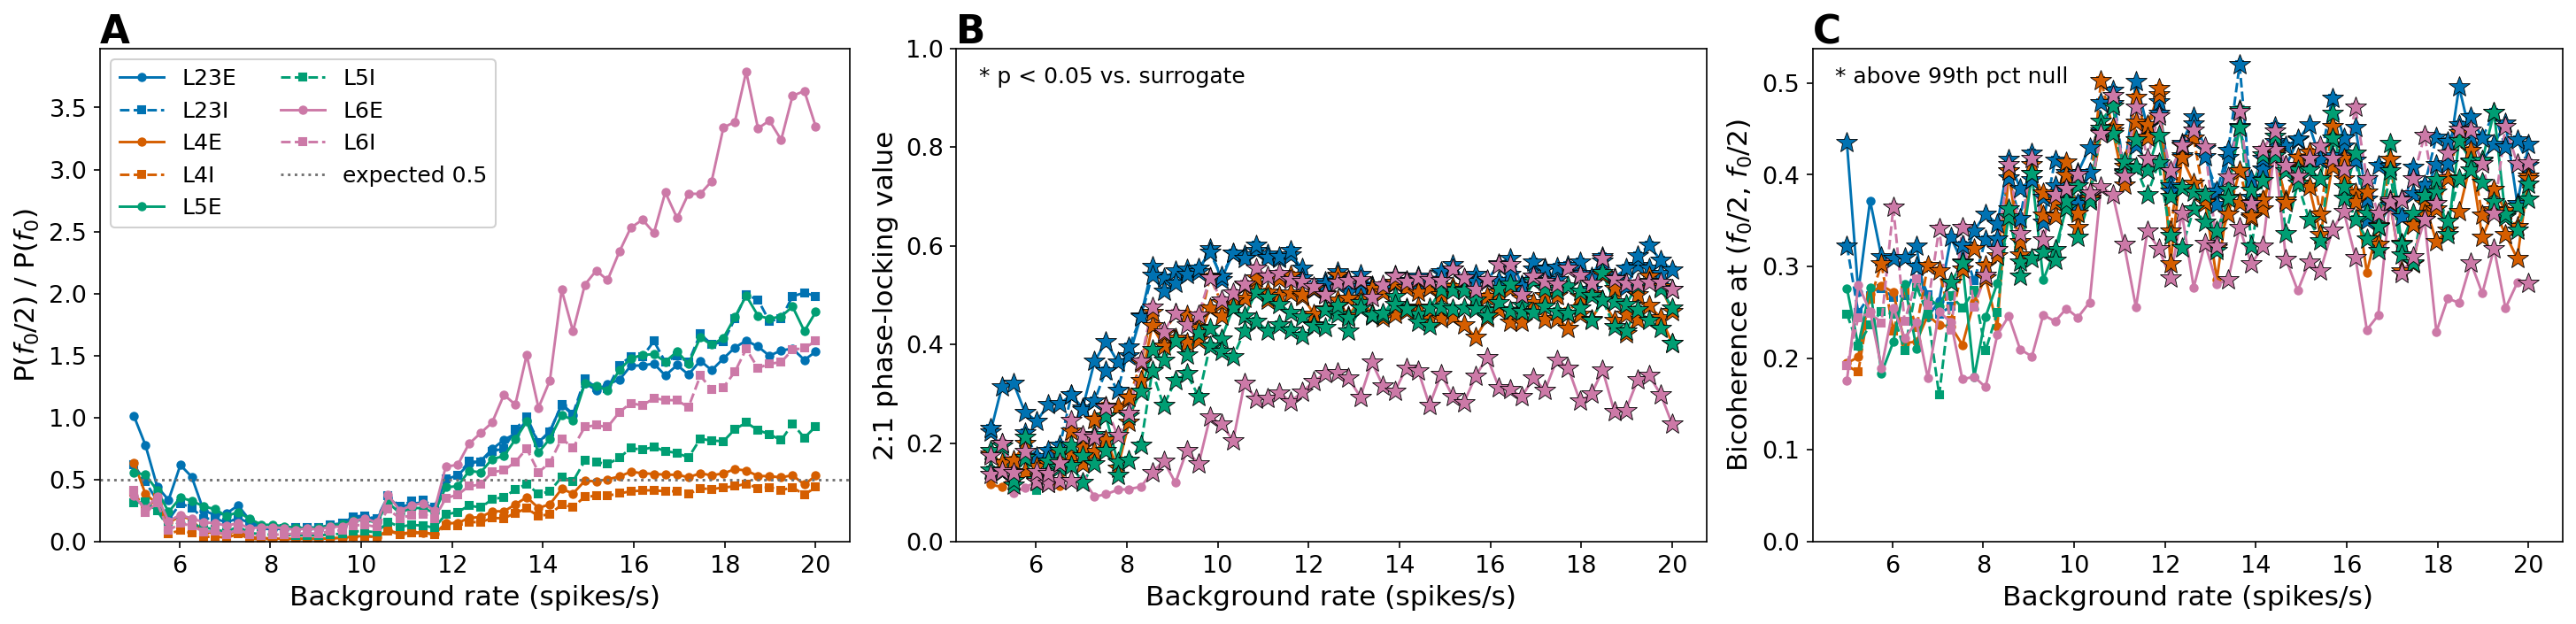

In [2]:
# --- Final panel: subharmonic power ratio, 2:1 phase locking, bicoherence ----
# One row of three, in the structure of the agreed mockup. Standalone: reads
# the npz written by the driver, so it also works right after a kernel restart
# without re-running the sweep.

import os
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt

OUT_NPZ = os.path.join("Figure2", "phase_locking_bicoherence.npz")

# PAPER_STYLE = False reproduces the mockup look: one colour per population
# (matplotlib default cycle) and panel titles carrying the star key.
# PAPER_STYLE = True applies the agreed paper figure style instead: layer
# colours (L2/3 #0072B2, L4 #D55E00, L5 #009E73, L6 #CC79A7), excitatory
# solid with circle markers, inhibitory dashed with square markers, no panel
# titles (the star key moves into the panels), bold A/B/C labels, larger fonts.
PAPER_STYLE = True
EXPECTED_RATIO = 0.5

d = np.load(OUT_NPZ, allow_pickle=False)
cfg = json.loads(str(d["config"]))
names = [str(s) for s in d["names"]]
bg = np.asarray(d["bg_rates"], dtype=float)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)  # all-NaN slices are fine
    Ratio_mean = np.nanmean(d["Ratio"], axis=1)
    Lambda_mean = np.nanmean(d["Lambda"], axis=1)
    Bicoh_mean = np.nanmean(d["Bicoh"], axis=1)
Lambda_sig = d["Lambda_sig"].astype(bool)
Bicoh_sig = d["Bicoh_sig"].astype(bool)
alpha_plv = cfg.get("ALPHA_PLV", 0.05)
alpha_bic = cfg.get("ALPHA_BIC", 0.01)

if PAPER_STYLE:
    layer_col = {"L23": "#0072B2", "L4": "#D55E00", "L5": "#009E73", "L6": "#CC79A7"}
    def _style(nm):
        col = layer_col[nm[:-1]]
        if nm.endswith("E"):
            return dict(color=col, ls="-", marker="o")
        return dict(color=col, ls="--", marker="s")
    FS = 15
else:
    _cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    def _style(nm):
        return dict(color=_cycle[names.index(nm) % len(_cycle)], ls="-", marker=".")
    FS = 12

fig, (axr, axl, axb) = plt.subplots(1, 3, figsize=(19.5, 4.8), dpi=150)

# panel 1: subharmonic power ratio
for p, nm in enumerate(names):
    axr.plot(bg, Ratio_mean[:, p], lw=1.4, ms=4, label=nm, **_style(nm))
axr.axhline(EXPECTED_RATIO, color="0.45", ls=":", lw=1.4,
            label=f"expected {EXPECTED_RATIO}")
axr.set_ylabel(r"P($f_0$/2) / P($f_0$)", fontsize=FS)
axr.set_ylim(bottom=0)
axr.legend(ncol=2, fontsize=FS - 3, loc="upper left", framealpha=0.9)

# panels 2 and 3: statistic plus significance stars
def _stat_panel(ax, mean_vals, sig, ylabel):
    for p, nm in enumerate(names):
        st = _style(nm)
        ax.plot(bg, mean_vals[:, p], lw=1.4, ms=4, **st)
        s = sig[:, p] & np.isfinite(mean_vals[:, p])
        if np.any(s):
            ax.plot(bg[s], mean_vals[s, p], ls="none", marker="*", ms=12,
                    color=st["color"], mec="k", mew=0.4, zorder=5)
    ax.set_ylabel(ylabel, fontsize=FS)

_stat_panel(axl, Lambda_mean, Lambda_sig, "2:1 phase-locking value")
axl.set_ylim(0, 1)
_stat_panel(axb, Bicoh_mean, Bicoh_sig, r"Bicoherence at ($f_0$/2, $f_0$/2)")
axb.set_ylim(bottom=0)

for ax in (axr, axl, axb):
    ax.set_xlabel("Background rate (spikes/s)", fontsize=FS)
    ax.tick_params(labelsize=FS - 2)

for ax, lab in zip((axr, axl, axb), "ABC"):
    ax.text(-0.0, 1.01, lab, transform=ax.transAxes,
            fontsize=FS + 6, fontweight="bold")

if PAPER_STYLE:
    axl.text(0.03, 0.93, f"* p < {alpha_plv:g} vs. surrogate",
             transform=axl.transAxes, fontsize=FS - 3)
    axb.text(0.03, 0.93, f"* above {round((1 - alpha_bic) * 100)}th pct null",
             transform=axb.transAxes, fontsize=FS - 3)
else:
    axr.set_title("Subharmonic power ratio", fontsize=FS)
    axl.set_title(f"Phase locking (* = p<{alpha_plv:g} vs. surrogate)", fontsize=FS)
    axb.set_title(f"Bicoherence (* = above {round((1 - alpha_bic) * 100)}th pct null)",
                  fontsize=FS)

plt.tight_layout()
os.makedirs("Figure2", exist_ok=True)
plt.savefig("Figure2/subharmonic_tests.svg", bbox_inches="tight")
plt.savefig("Figure2/subharmonic_tests.png", bbox_inches="tight", dpi=300)
plt.show()


In [1]:
import numpy as np
d = np.load("Figure2/phase_locking_bicoherence.npz")
bg = d["bg_rates"]; names = [str(s) for s in d["names"]]
sig = d["Lambda_sig"].astype(bool)
for p, nm in enumerate(names):
    idx = np.flatnonzero(sig[:, p])
    first = bg[idx[0]] if idx.size else None
    print(f"{nm}: first significant at {first}, fraction {sig[:, p].mean():.2f}")
print("f0 range:", np.nanmin(d["F0"]), "-", np.nanmax(d["F0"]))

L23E: first significant at 5.0, fraction 1.00
L23I: first significant at 5.0, fraction 1.00
L4E: first significant at 5.51, fraction 0.95
L4I: first significant at 5.0, fraction 1.00
L5E: first significant at 5.0, fraction 1.00
L5I: first significant at 5.0, fraction 0.98
L6E: first significant at 5.0, fraction 0.85
L6I: first significant at 5.0, fraction 1.00
f0 range: 60.0 - 96.0
